In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load the Breast Cancer Wisconsin dataset
col_names = [
    "id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean","radius_se",
    "texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave_points_se",
    "symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst",
    "smoothness_worst","compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]
df = pd.read_csv("wdbc.data", header=None, names=col_names)
X = df.drop(["id", "diagnosis"], axis=1) #feature
y = df["diagnosis"] #target

In [3]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.25, random_state=42, shuffle=True, stratify=y #even out benign v/s malignant counts
)

In [4]:
# Display first 5 rows
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# Create a Decision Tree model
from sklearn.tree import DecisionTreeClassifier
# Build and train
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=4,          # limit how deep the tree can grow
    min_samples_split=10, # minimum samples needed to split a node
    min_samples_leaf=5    # minimum samples required at a leaf node
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

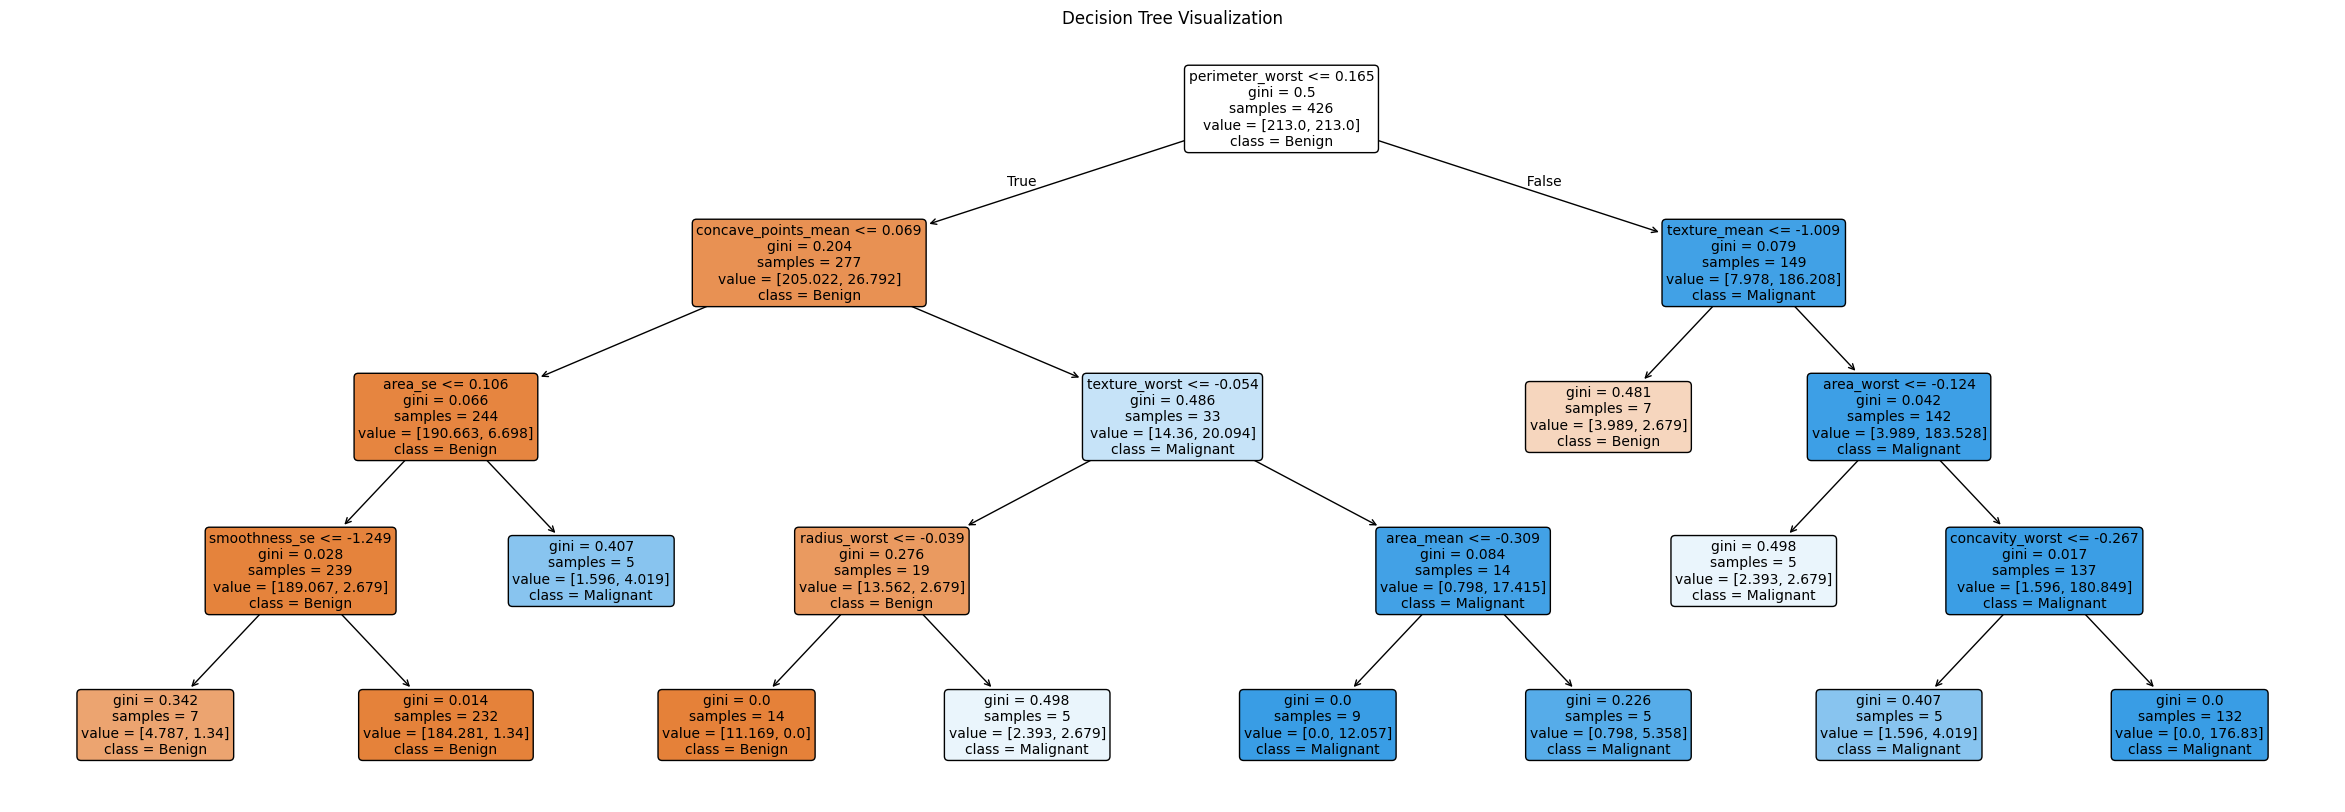

In [9]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(30, 10))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=["Benign", "Malignant"],
    filled=True,           # color nodes by class
    rounded=True,          # rounded boxes
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()

In [10]:
# Train random forest model
from sklearn.ensemble import RandomForestClassifier

# Build and train
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# Extract feature importances
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [14]:
# Print feature importance
importances['importance_pct'] = importances['importance'].map('{:.2%}'.format)

print(importances[['feature', 'importance_pct']])

                    feature importance_pct
27     concave_points_worst         12.68%
23               area_worst         12.08%
7       concave_points_mean         11.27%
20             radius_worst          9.26%
2            perimeter_mean          8.52%
22          perimeter_worst          8.19%
0               radius_mean          6.40%
6            concavity_mean          5.36%
26          concavity_worst          3.65%
3                 area_mean          3.08%
13                  area_se          2.85%
21            texture_worst          2.02%
25        compactness_worst          1.72%
10                radius_se          1.40%
1              texture_mean          1.36%
5          compactness_mean          1.27%
24         smoothness_worst          1.15%
12             perimeter_se          1.02%
28           symmetry_worst          0.95%
4           smoothness_mean          0.90%
16             concavity_se          0.69%
15           compactness_se          0.64%
29  fractal

In [16]:
# Build and train an AdaBoostClassifier on your training data.
from sklearn.ensemble import AdaBoostClassifier
# Build and train
ada = AdaBoostClassifier(
    n_estimators=100,      # number of weak learners
    learning_rate=1.0,     # contribution of each weak learner
    random_state=42
)
ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [17]:
# Evaluate models
from sklearn.metrics import accuracy_score

models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'AdaBoost': ada
}

print(f"{'Model':<20} {'Train Accuracy':<20} {'Test Accuracy':<20}")
print("-" * 60)
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<20} {train_acc:<20.2%} {test_acc:<20.2%}")

Model                Train Accuracy       Test Accuracy       
------------------------------------------------------------
Decision Tree        96.48%               92.31%              
Random Forest        100.00%              97.20%              
AdaBoost             100.00%              97.90%              


In [18]:
# Experiment with hyperparameters
from sklearn.metrics import accuracy_score

# Decision Tree experiments
dt_experiments = [
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=3),
    DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=5),
    DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=5, min_samples_split=10),
]

# Random Forest experiments
rf_experiments = [
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=50),
    RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=200),
    RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=200, max_depth=5),
]

# AdaBoost experiments
ada_experiments = [
    AdaBoostClassifier(random_state=42),
    AdaBoostClassifier(random_state=42, n_estimators=50),
    AdaBoostClassifier(random_state=42, n_estimators=200),
    AdaBoostClassifier(random_state=42, n_estimators=200, learning_rate=0.5),
]

# Evaluate all experiments
def evaluate_experiments(experiments, model_name):
    print(f"\n{model_name}")
    print(f"{'Hyperparameters':<60} {'Train':>10} {'Test':>10}")
    print("-" * 82)
    for model in experiments:
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        # extract key hyperparameters
        params = {k: v for k, v in model.get_params().items() 
                  if v != model.__class__().get_params().get(k)}
        print(f"{str(params):<60} {train_acc:>10.2%} {test_acc:>10.2%}")

evaluate_experiments(dt_experiments, "DECISION TREE")
evaluate_experiments(rf_experiments, "RANDOM FOREST")
evaluate_experiments(ada_experiments, "ADABOOST")


DECISION TREE
Hyperparameters                                                   Train       Test
----------------------------------------------------------------------------------
{'class_weight': 'balanced', 'random_state': 42}                100.00%     92.31%
{'class_weight': 'balanced', 'max_depth': 3, 'random_state': 42}     97.18%     93.01%
{'class_weight': 'balanced', 'max_depth': 5, 'random_state': 42}     99.53%     93.71%
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10, 'random_state': 42}     96.95%     93.01%

RANDOM FOREST
Hyperparameters                                                   Train       Test
----------------------------------------------------------------------------------
{'class_weight': 'balanced', 'random_state': 42}                100.00%     97.20%
{'class_weight': 'balanced', 'n_estimators': 50, 'random_state': 42}    100.00%     95.10%
{'class_weight': 'balanced', 'n_estimators': 200, 'random_state': 42}    100.00%     96.50%
{'c